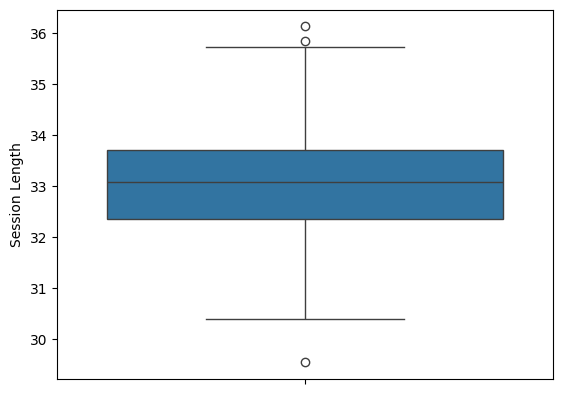

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('Customers.csv')

sns.boxplot(data=df, y='Session Length')
plt.show()

# All numerical columns
numeric_columns = df.select_dtypes(include=['number']).columns

# Remove outliers using IQR
for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]
    
df.to_csv('train.csv', index=False)